# W2 — Data Exploration: ChestMNIST

**Dataset:** ChestMNIST (MedMNIST) — 112,120 chest X-rays, 14 pathology labels (multi-label binary)  
**Splits:** Train 78,468 | Val 11,219 | Test 22,433  
**Seed:** 42 (fixed everywhere)

### Sections
1. Setup & Data Loading  
2. Class Imbalance Analysis  
3. Visualizations  
4. Preprocessing Decisions  
5. Loss Function Analysis (BCE vs weighted BCE)  
6. Conclusions

In [ ]:
# ============================================================
# INSTALLATION CELL (RUN ONLY ONCE)
# ============================================================
# This project uses:
# - PyTorch (CPU version)
# - Torchvision (image utilities + transforms)
# - Torchaudio (optional dependency of torch ecosystem)
# - NumPy (required for MedMNIST + torchvision transforms)
# - MedMNIST (medical imaging datasets)
#
# IMPORTANT NOTES:
# - Make sure to restart kernel after running this cell
# - If using VS Code, ensure correct Python interpreter is selected
# - This setup is tested for CPU + Python 3.11/3.12 (with numpy 1.x)
# ============================================================

# --- Uninstall conflicting versions first ---
# !pip uninstall -y torch torchvision torchaudio numpy

# --- Install compatible CPU versions ---
# !pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1

# --- Fix NumPy compatibility issue (IMPORTANT) ---
# !pip install numpy==1.26.4

# --- Install dataset library ---
# !pip install medmnist

# --- Optional but useful utilities ---
# !pip install matplotlib pandas scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import os
import torch
import random
from torch.utils.data import Dataset, DataLoader

LABEL_NAMES = ['Atelectasis','Cardiomegaly','Effusion','Infiltration','Mass','Nodule','Pneumonia','Pneumothorax','Consolidation','Edema','Emphysema','Fibrosis','Pleural_Thickening','Hernia']

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("? imports done")
print(f"Using seed: {SEED}")



? imports done
Using seed: 42


In [2]:
import numpy as np
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/ineskel/medical_mlops/amal/setup/data/chestmnist.npz"

response = requests.get(url)
data = np.load(BytesIO(response.content))

print("Keys:", list(data.keys()))

Keys: ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']


In [3]:
X_train = data['train_images']
y_train = data['train_labels'].astype(np.float32)
X_val   = data['val_images']
y_val   = data['val_labels'].astype(np.float32)
X_test  = data['test_images']
y_test  = data['test_labels'].astype(np.float32)

print("Train:", X_train.shape, X_train.dtype)
print("Val:  ", X_val.shape, X_val.dtype)
print("Test: ", X_test.shape, X_test.dtype)

Train: (78468, 28, 28) uint8
Val:   (11219, 28, 28) uint8
Test:  (22433, 28, 28) uint8


In [4]:
# ── Data integrity check ──────────────────────────────────────────────────────
print("=== Missing / corrupt check ===")
print(f"NaN in X_train: {np.isnan(X_train.astype(np.float32)).sum()}")
print(f"NaN in y_train: {np.isnan(y_train).sum()}")
print(f"Pixel range — min: {X_train.min()}  max: {X_train.max()}  dtype: {X_train.dtype}")
print(f"Label range — min: {int(y_train.min())}  max: {int(y_train.max())}  unique: {np.unique(y_train)}")
print(f"Any all-zero image (blank): {(X_train.reshape(len(X_train), -1).sum(axis=1) == 0).sum()}")
print("✓ No missing data found" )

=== Missing / corrupt check ===
NaN in X_train: 0
NaN in y_train: 0
Pixel range — min: 0  max: 253  dtype: uint8
Label range — min: 0  max: 1  unique: [0. 1.]
Any all-zero image (blank): 0
✓ No missing data found


In [5]:
pos_counts = y_train.sum(axis=0)
neg_counts = len(y_train) - pos_counts

print("=== Class imbalance (train) ===")
for i, name in enumerate(LABEL_NAMES):
    print(f"{name:<20} pos={int(pos_counts[i]):>6}  neg={int(neg_counts[i]):>6}  ratio={neg_counts[i]/max(pos_counts[i], 1):.1f}x")

# Useful if you later use BCEWithLogitsLoss
pos_weight = torch.tensor(neg_counts / np.maximum(pos_counts, 1), dtype=torch.float32)
print("\nSuggested pos_weight for BCEWithLogitsLoss ready (shape):", tuple(pos_weight.shape))

=== Class imbalance (train) ===
Atelectasis          pos=  7996  neg= 70472  ratio=8.8x
Cardiomegaly         pos=  1950  neg= 76518  ratio=39.2x
Effusion             pos=  9261  neg= 69207  ratio=7.5x
Infiltration         pos= 13914  neg= 64554  ratio=4.6x
Mass                 pos=  3988  neg= 74480  ratio=18.7x
Nodule               pos=  4375  neg= 74093  ratio=16.9x
Pneumonia            pos=   978  neg= 77490  ratio=79.2x
Pneumothorax         pos=  3705  neg= 74763  ratio=20.2x
Consolidation        pos=  3263  neg= 75205  ratio=23.0x
Edema                pos=  1690  neg= 76778  ratio=45.4x
Emphysema            pos=  1799  neg= 76669  ratio=42.6x
Fibrosis             pos=  1158  neg= 77310  ratio=66.8x
Pleural_Thickening   pos=  2279  neg= 76189  ratio=33.4x
Hernia               pos=   144  neg= 78324  ratio=543.9x

Suggested pos_weight for BCEWithLogitsLoss ready (shape): (14,)


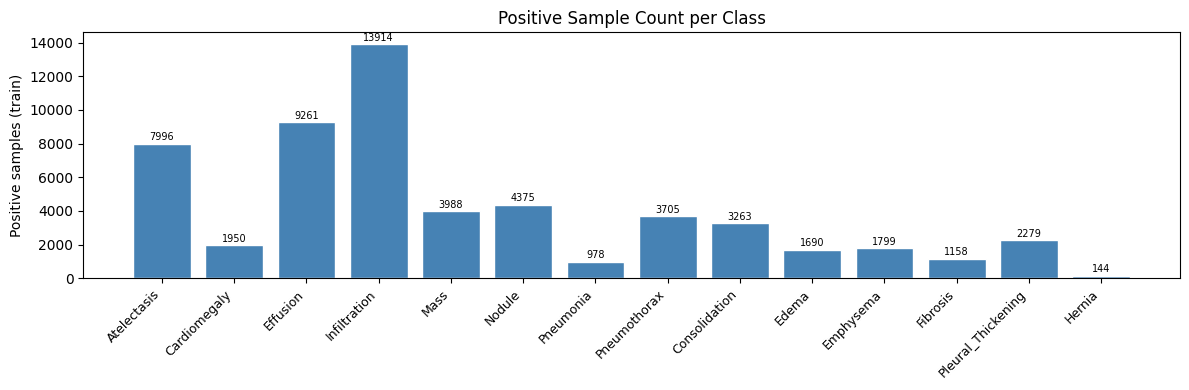

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(LABEL_NAMES))
bars = ax.bar(x, pos_counts, color='steelblue', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Positive samples (train)")
ax.set_title("Positive Sample Count per Class")
for bar, cnt in zip(bars, pos_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            str(int(cnt)), ha='center', va='bottom', fontsize=7)
plt.tight_layout(); 
plt.savefig("../figures/positive_sample_count_per_class.png",dpi=300,bbox_inches='tight')
plt.show()

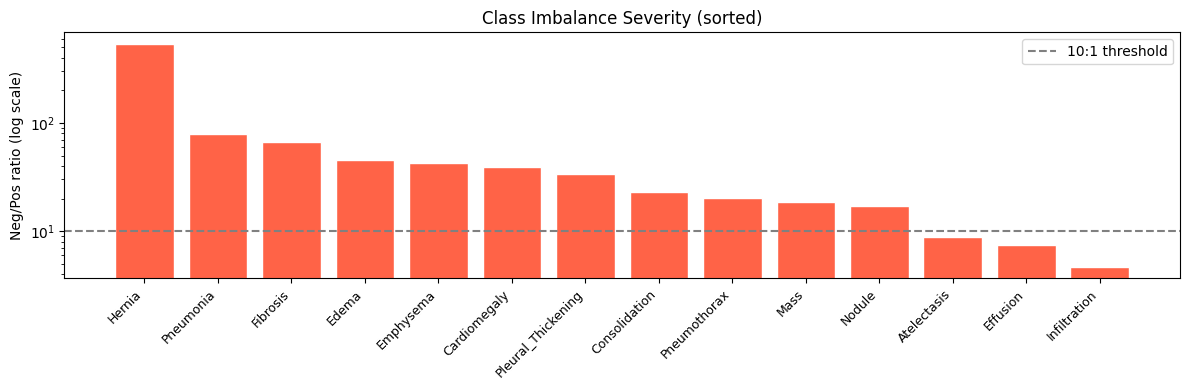

In [7]:
ratios = neg_counts / np.maximum(pos_counts, 1)
order = np.argsort(ratios)[::-1]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(np.arange(14), ratios[order], color='tomato', edgecolor='white')
ax.set_xticks(np.arange(14))
ax.set_xticklabels([LABEL_NAMES[i] for i in order], rotation=45, ha='right', fontsize=9)
ax.set_yscale('log')
ax.set_ylabel("Neg/Pos ratio (log scale)")
ax.set_title("Class Imbalance Severity (sorted)")
ax.axhline(10, color='gray', linestyle='--', label='10:1 threshold')
ax.legend()
plt.tight_layout()
plt.savefig("../figures/class_imbalance_severity.png",dpi=300,bbox_inches='tight')
plt.show()

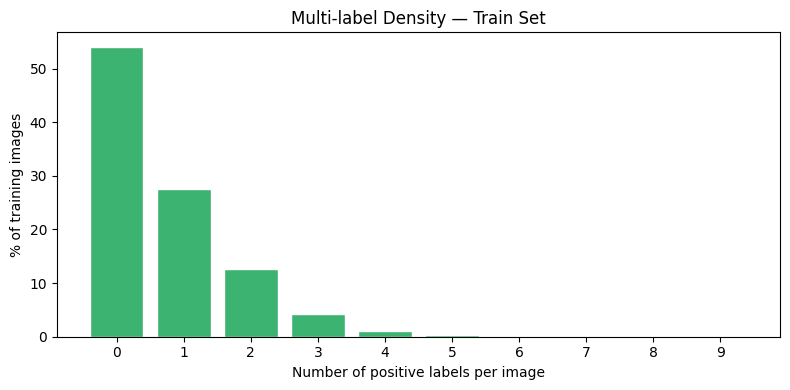

No finding: 42405 (54.0%)
Max labels on one image: 9
Mean labels per image:   0.72


In [8]:
labels_per_image = y_train.sum(axis=1).astype(int)
unique, counts = np.unique(labels_per_image, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(unique, counts / len(y_train) * 100, color='mediumseagreen', edgecolor='white')
ax.set_xlabel("Number of positive labels per image")
ax.set_ylabel("% of training images")
ax.set_title("Multi-label Density — Train Set")
ax.set_xticks(unique)
plt.tight_layout(); 
plt.savefig("../figures/multi_label_density.png",dpi=300,bbox_inches='tight')
plt.show()

print(f"No finding: {(labels_per_image==0).sum()} ({(labels_per_image==0).mean()*100:.1f}%)")
print(f"Max labels on one image: {labels_per_image.max()}")
print(f"Mean labels per image:   {labels_per_image.mean():.2f}")

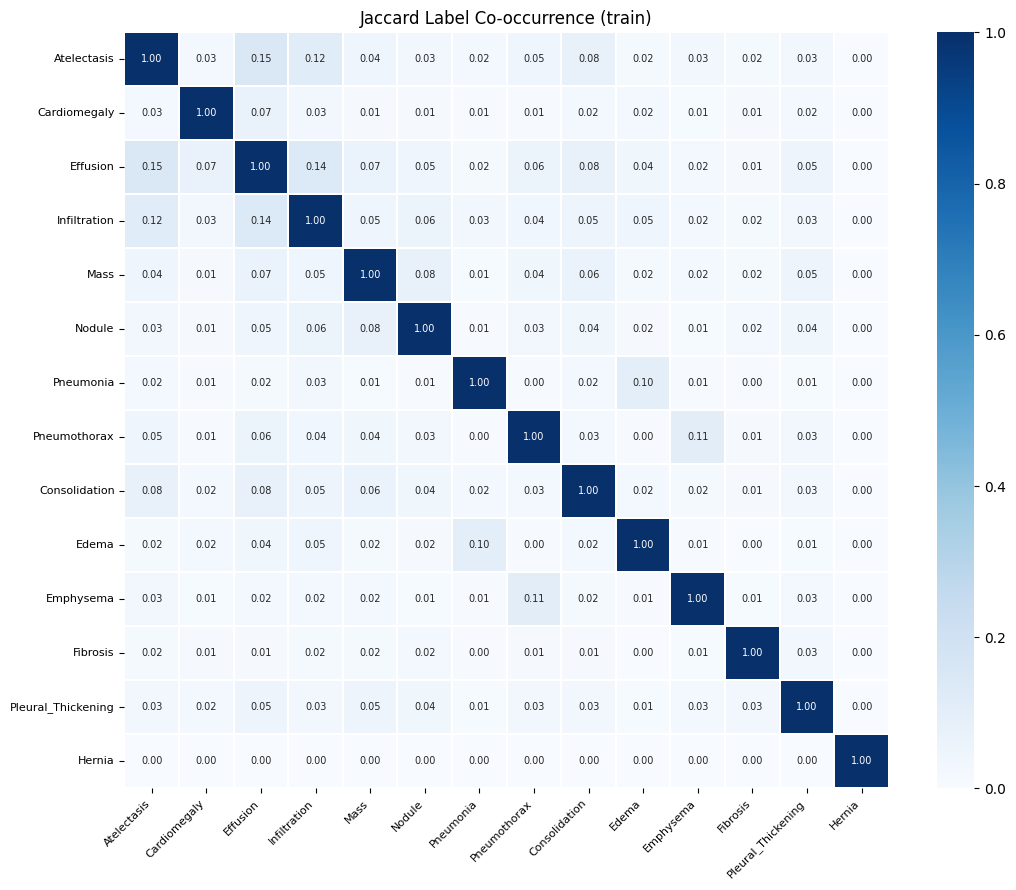

In [9]:
import seaborn as sns

n = len(LABEL_NAMES)
cooc = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        both   = ((y_train[:, i] == 1) & (y_train[:, j] == 1)).sum()
        either = ((y_train[:, i] == 1) | (y_train[:, j] == 1)).sum()
        cooc[i, j] = both / max(either, 1)  # Jaccard

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cooc, xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            annot=True, fmt='.2f', cmap='Blues', linewidths=0.3,
            ax=ax, annot_kws={'size': 7})
ax.set_title("Jaccard Label Co-occurrence (train)")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout(); 
plt.savefig("../figures/jaccard_label_co-occurrence.png",dpi=300,bbox_inches='tight')
plt.show()

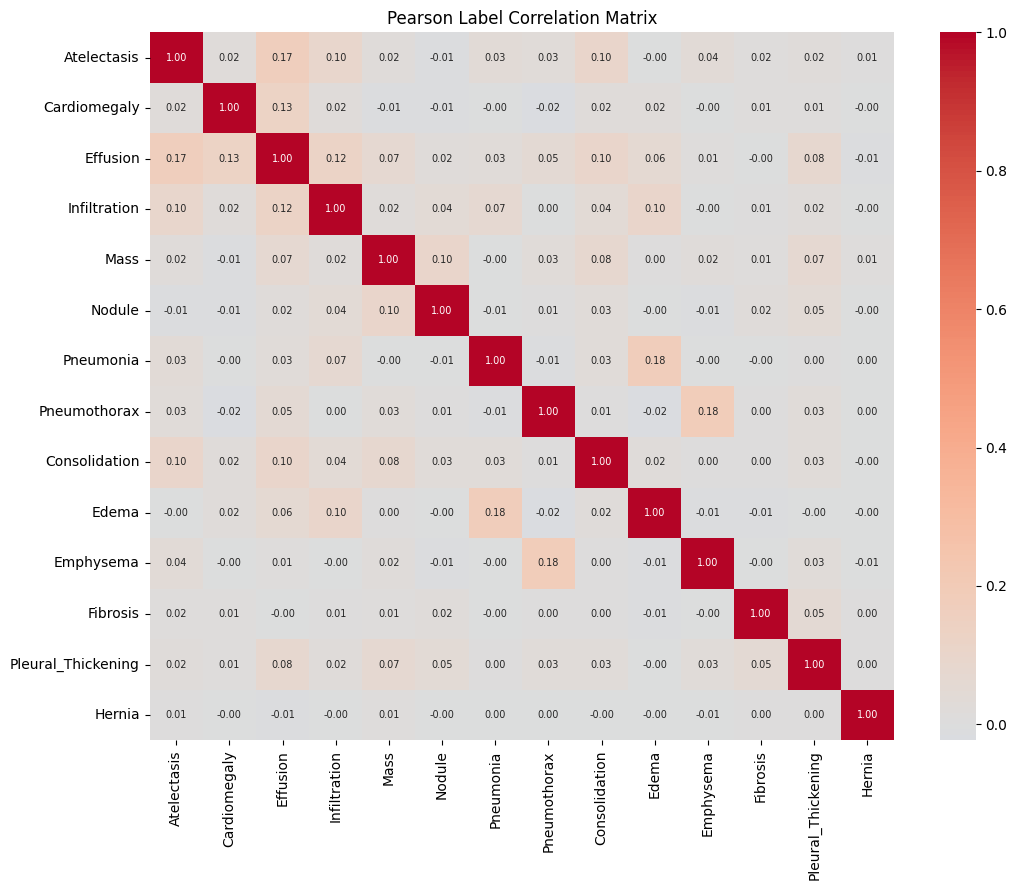

In [10]:
label_df = pd.DataFrame(y_train, columns=LABEL_NAMES)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(label_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 7})
ax.set_title("Pearson Label Correlation Matrix")
plt.tight_layout()
plt.savefig("../figures/pearson_label_co-occurrence.png",dpi=300,bbox_inches='tight')
plt.show()

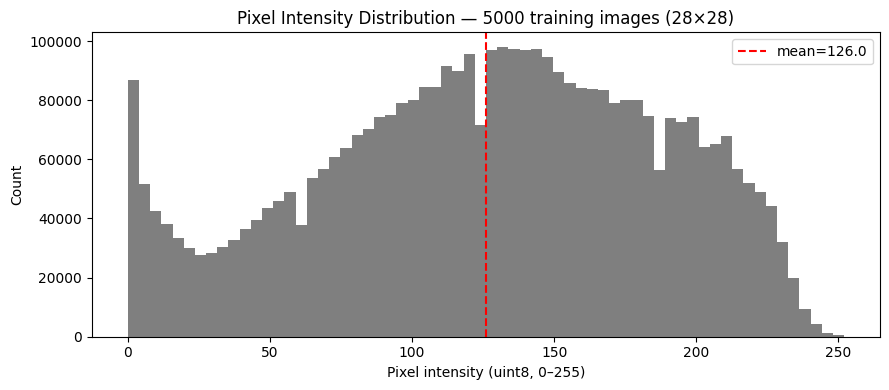

Mean=125.96  Std=60.37  Min=0  Max=252


In [11]:
sample_idx = np.random.choice(len(X_train), 5000, replace=False)
pixel_vals = X_train[sample_idx].flatten()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pixel_vals, bins=64, color='dimgray', edgecolor='none', alpha=0.85)
ax.set_xlabel("Pixel intensity (uint8, 0–255)")
ax.set_ylabel("Count")
ax.set_title("Pixel Intensity Distribution — 5000 training images (28×28)")
ax.axvline(pixel_vals.mean(), color='red', linestyle='--',
           label=f'mean={pixel_vals.mean():.1f}')
ax.legend(); plt.tight_layout(); 
plt.savefig("../figures/pixel_intensity_distribution.png",dpi=300,bbox_inches='tight')
plt.show()
print(f"Mean={pixel_vals.mean():.2f}  Std={pixel_vals.std():.2f}  Min={pixel_vals.min()}  Max={pixel_vals.max()}")

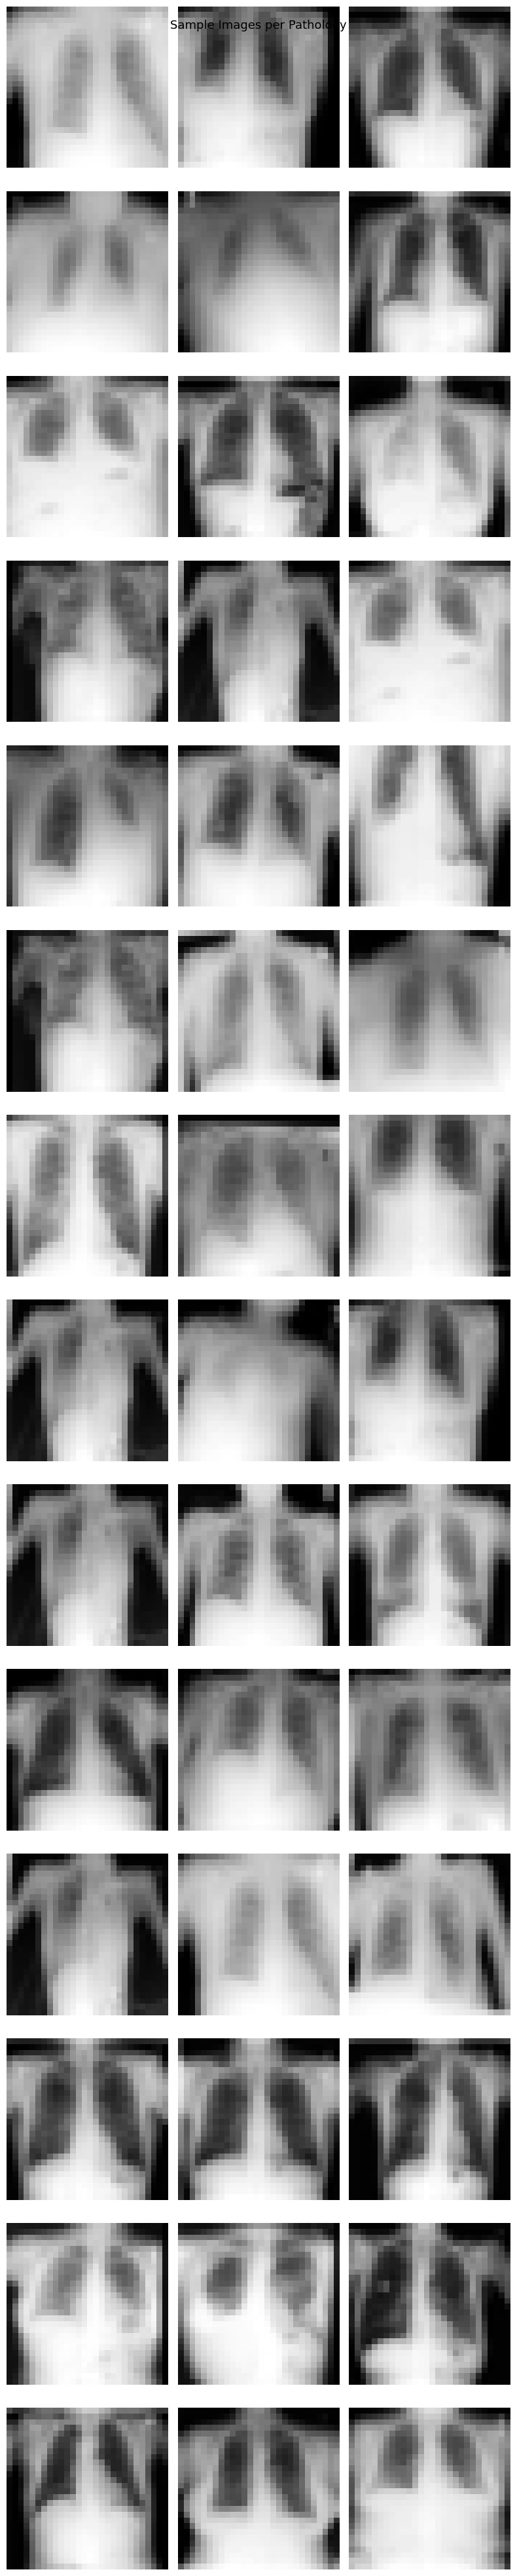

In [12]:
fig, axes = plt.subplots(14, 3, figsize=(8, 40))
for i, name in enumerate(LABEL_NAMES):
    idxs = np.where(y_train[:, i] == 1)[0][:3]
    for j, idx in enumerate(idxs):
        axes[i, j].imshow(X_train[idx], cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(name, fontsize=8, rotation=0, labelpad=60, va='center')
plt.suptitle("Sample Images per Pathology", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/sample_images_per_pathology.png",dpi=300,bbox_inches='tight')
plt.show()

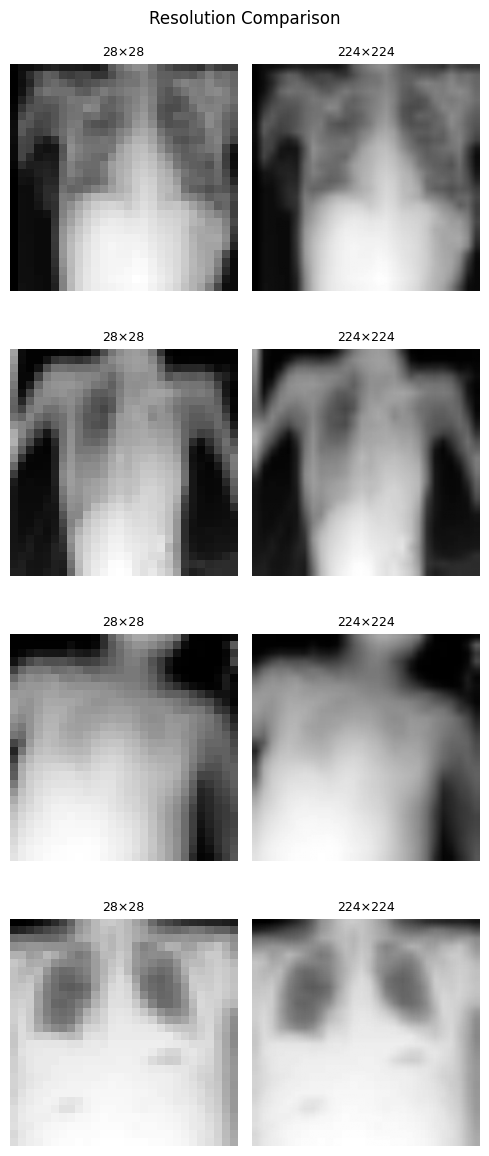

In [13]:
from PIL import Image

examples = [i for i in range(len(X_train)) if y_train[i].sum() > 0][:4]
fig, axes = plt.subplots(4, 2, figsize=(5, 12))
for row, idx in enumerate(examples):
    raw     = X_train[idx]  # (28, 28) uint8
    resized = np.array(Image.fromarray(raw).resize((224, 224), Image.BILINEAR))
    active  = [LABEL_NAMES[j] for j, v in enumerate(y_train[idx]) if v == 1]
    axes[row, 0].imshow(raw,     cmap='gray'); axes[row, 0].set_title('28×28',   fontsize=9)
    axes[row, 1].imshow(resized, cmap='gray'); axes[row, 1].set_title('224×224', fontsize=9)
    axes[row, 0].set_ylabel(', '.join(active), fontsize=7, rotation=0, labelpad=65, va='center')
    for ax in axes[row]: ax.axis('off')
plt.suptitle("Resolution Comparison", fontsize=12)
plt.tight_layout(); 
plt.savefig("../figures/resolution_comparison.png",dpi=300,bbox_inches='tight')
plt.show()

In [14]:

import torch
from torch.utils.data import DataLoader

import medmnist
from medmnist import ChestMNIST, INFO

from torchvision import transforms

# Reproducibility
SEED = 42
torch.manual_seed(SEED)

# ── Transforms ─────────────────────────────────────────────
def get_transforms(split):
    normalize = transforms.Normalize(mean=[0.5], std=[0.5])

    if split == "train":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize,
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            normalize,
        ])

# ── Generator ──────────────────────────────────────────────
generator = torch.Generator().manual_seed(SEED)

# ── Datasets ───────────────────────────────────────────────
train_dataset = ChestMNIST(
    split="train",
    transform=get_transforms("train"),
    download=True
)

val_dataset = ChestMNIST(
    split="val",
    transform=get_transforms("val"),
    download=True
)

test_dataset = ChestMNIST(
    split="test",
    transform=get_transforms("test"),
    download=True
)

# ── DataLoaders ────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,   # safer on Windows/VSCODE CPU
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# ── Check ──────────────────────────────────────────────────
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# ── Test one batch ─────────────────────────────────────────
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Using downloaded and verified file: C:\Users\probook\.medmnist\chestmnist.npz
Using downloaded and verified file: C:\Users\probook\.medmnist\chestmnist.npz
Using downloaded and verified file: C:\Users\probook\.medmnist\chestmnist.npz
Train samples: 78468
Val samples:   11219
Test samples:  22433
Train batches: 2453
Val batches:   351
Test batches:  702
Images shape: torch.Size([32, 1, 224, 224])
Labels shape: torch.Size([32, 14])


In [23]:
imgs, labels = next(iter(train_loader))

print("Batch image shape:", imgs.shape)    # expect (32, 1, 224, 224)
print("Batch label shape:", labels.shape)  # expect (32, 14)
print("Pixel range:      ", imgs.min().item(), "-", imgs.max().item())  # expect 0.0 - 1.0
print("Label sample:\n", labels[0])        # binary vector of 14

Batch image shape: torch.Size([32, 1, 224, 224])
Batch label shape: torch.Size([32, 14])
Pixel range:       -1.0 - 0.9058823585510254
Label sample:
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32)


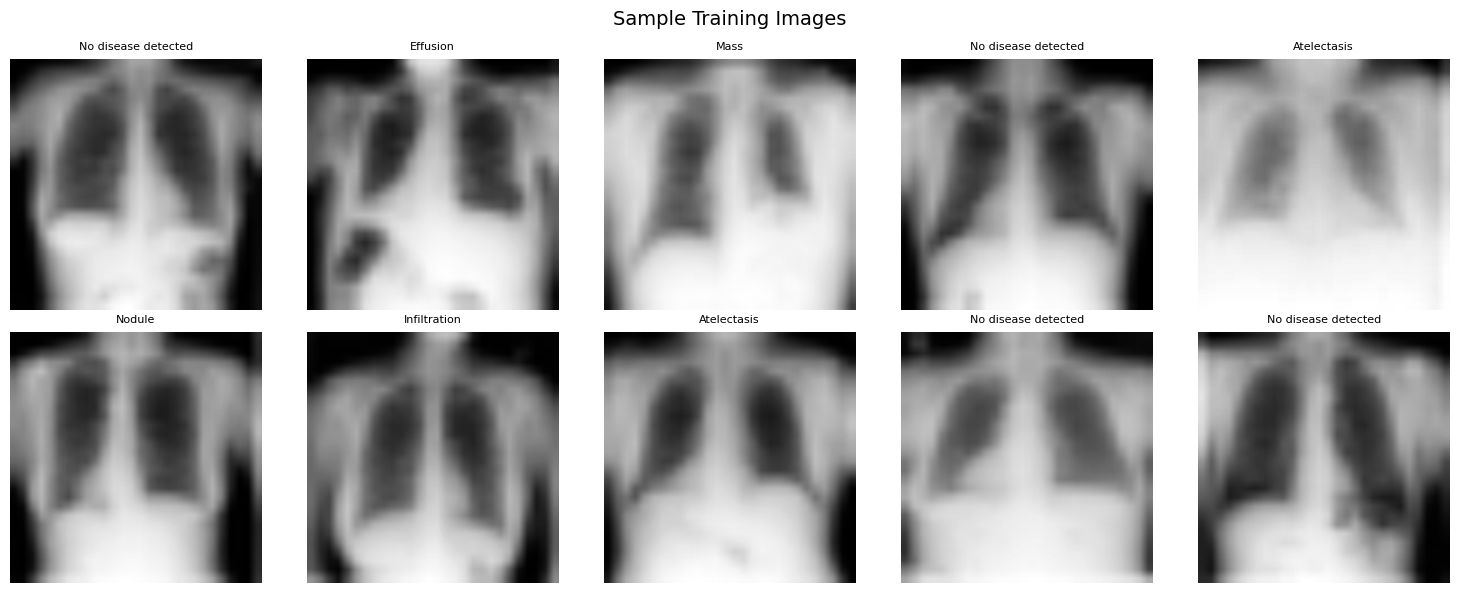

In [24]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    active = [LABEL_NAMES[j] for j, v in enumerate(labels[i].int().tolist()) if v == 1]
    title = ', '.join(active) if active else 'No disease detected'
    ax.set_title(title, fontsize=8)
    ax.axis('off')
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/sample_training_images.png",dpi=300,bbox_inches='tight')
plt.show()

In [25]:
print("=== Dataset Sizes ===")
print(f"Train:      {len(train_dataset):>6} images | {len(train_loader):>4} batches")
print(f"Validation: {len(val_dataset):>6} images | {len(val_loader):>4} batches")
print(f"Test:       {len(test_dataset):>6} images | {len(test_loader):>4} batches")
print(f"Total:      {len(train_dataset)+len(val_dataset)+len(test_dataset):>6} images")
print(f"\nBatch size:  32")
print(f"Image shape: (1, 224, 224)")
print(f"Label shape: (14,) — multi-label binary")

=== Dataset Sizes ===
Train:       78468 images | 2453 batches
Validation:  11219 images |  351 batches
Test:        22433 images |  702 batches
Total:      112120 images

Batch size:  32
Image shape: (1, 224, 224)
Label shape: (14,) — multi-label binary


In [26]:
from tqdm import tqdm
# Quick imbalance experiment: BCE vs BCE + pos_weight
import copy
def build_tiny_model():
    return torch.nn.Sequential(
        torch.nn.Conv2d(1, 8, kernel_size=3, padding=1),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(2),
        torch.nn.Conv2d(8, 16, kernel_size=3, padding=1),
        torch.nn.ReLU(),
        torch.nn.AdaptiveAvgPool2d((1, 1)),
        torch.nn.Flatten(),
        torch.nn.Linear(16, len(LABEL_NAMES))
    )
def evaluate_multilabel(model, loader, device, max_batches=40, threshold=0.5):
    model.eval()
    tp = torch.zeros(len(LABEL_NAMES), device=device)
    fp = torch.zeros(len(LABEL_NAMES), device=device)
    fn = torch.zeros(len(LABEL_NAMES), device=device)
    with torch.no_grad():
        for b, (x, y) in enumerate(loader):
            if b >= max_batches:
                break
            x = x.to(device)
            y = y.float().to(device) 
            p = (torch.sigmoid(model(x)) >= threshold).float()
            tp += (p * y).sum(0)
            fp += (p * (1 - y)).sum(0)
            fn += ((1 - p) * y).sum(0)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    macro = {
        'precision': precision.mean().item(),
        'recall': recall.mean().item(),
        'f1': f1.mean().item(),
    }
    return macro, precision.cpu(), recall.cpu(), f1.cpu()

def run_short_train(loss_fn, device, steps=120, lr=1e-3, label=""):
    torch.manual_seed(SEED)
    model = build_tiny_model().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    running_loss = 0.0
    step = 0

    pbar = tqdm(total=steps, desc=f"Training {label}", unit="step")

    while step < steps:
        for x, y in train_loader:
            x = x.to(device)
            y = y.float().to(device)
            opt.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            running_loss += loss.item()
            step += 1
            pbar.set_postfix(loss=f"{running_loss/step:.4f}")
            pbar.update(1)
            if step >= steps:
                break

    pbar.close()
    avg_loss = running_loss / steps
    print(f"  → Evaluating {label}...")
    macro, per_p, per_r, per_f1 = evaluate_multilabel(model, val_loader, device=device, max_batches=40)
    print(f"  → Done. macro F1={macro['f1']:.3f}")
    return avg_loss, macro, per_p, per_r, per_f1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

print("\n[1/2] Running baseline BCE...")
base_loss_fn = torch.nn.BCEWithLogitsLoss()
base_loss, base_macro, base_p, base_r, base_f1 = run_short_train(base_loss_fn, device=device, label="BCE")

print("\n[2/2] Running weighted BCE...")
weighted_loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
w_loss, w_macro, w_p, w_r, w_f1 = run_short_train(weighted_loss_fn, device=device, label="BCE+weight")

print('\n=== Quick Comparison (same tiny model, short run) ===')
print(f"Baseline BCE       | loss={base_loss:.4f} | macro P={base_macro['precision']:.3f} R={base_macro['recall']:.3f} F1={base_macro['f1']:.3f}")
print(f"BCE + pos_weight   | loss={w_loss:.4f} | macro P={w_macro['precision']:.3f} R={w_macro['recall']:.3f} F1={w_macro['f1']:.3f}")

print('\nPer-class recall change (weighted - baseline):')
recall_delta = w_r - base_r
for i, name in enumerate(LABEL_NAMES):
    print(f"{name:<20}  Δrecall={recall_delta[i].item():+0.3f}  base={base_r[i].item():0.3f}  weighted={w_r[i].item():0.3f}")

Device: cpu

[1/2] Running baseline BCE...


Training BCE: 100%|██████████| 120/120 [00:54<00:00,  2.20step/s, loss=0.4107]


  → Evaluating BCE...
  → Done. macro F1=0.000

[2/2] Running weighted BCE...


Training BCE+weight: 100%|██████████| 120/120 [01:00<00:00,  1.99step/s, loss=1.3631]


  → Evaluating BCE+weight...
  → Done. macro F1=0.062

=== Quick Comparison (same tiny model, short run) ===
Baseline BCE       | loss=0.4107 | macro P=0.000 R=0.000 F1=0.000
BCE + pos_weight   | loss=1.3631 | macro P=0.041 R=0.458 F1=0.062

Per-class recall change (weighted - baseline):
Atelectasis           Δrecall=+0.025  base=0.000  weighted=0.025
Cardiomegaly          Δrecall=+1.000  base=0.000  weighted=1.000
Effusion              Δrecall=+0.921  base=0.000  weighted=0.921
Infiltration          Δrecall=+1.000  base=0.000  weighted=1.000
Mass                  Δrecall=+0.000  base=0.000  weighted=0.000
Nodule                Δrecall=+0.951  base=0.000  weighted=0.951
Pneumonia             Δrecall=+0.000  base=0.000  weighted=0.000
Pneumothorax          Δrecall=+0.000  base=0.000  weighted=0.000
Consolidation         Δrecall=+0.340  base=0.000  weighted=0.340
Edema                 Δrecall=+0.000  base=0.000  weighted=0.000
Emphysema             Δrecall=+0.000  base=0.000  weighted=0.

In [28]:
print(LABEL_NAMES)
print("num names:", len(LABEL_NAMES), "| y_train dims:", y_train.shape[1])
assert len(LABEL_NAMES) == y_train.shape[1]

['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']
num names: 14 | y_train dims: 14


In [29]:
i = 0
active = [LABEL_NAMES[j] for j, v in enumerate(y_train[i]) if v == 1]
print("Raw vector:", y_train[i].astype(int).tolist())
print("Named labels:", active if active else ["No disease detected"])


Raw vector: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Named labels: ['No disease detected']


In [30]:
def decode_labels(vec, label_names=LABEL_NAMES):
    names = [label_names[i] for i, v in enumerate(vec) if int(v) == 1]
    return names if names else ["No finding"]


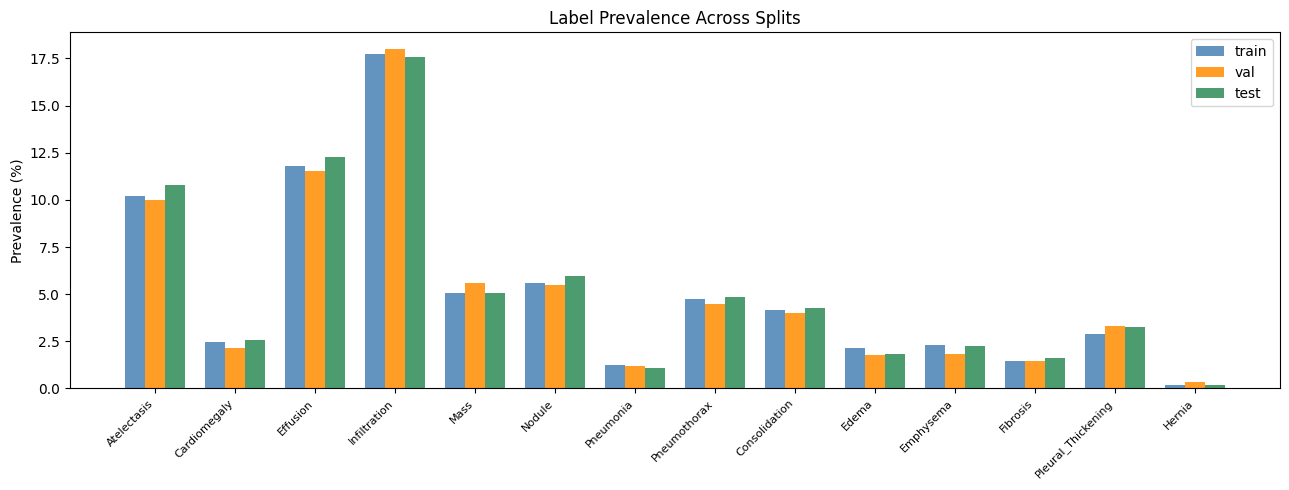

In [31]:
splits = {'train': y_train, 'val': y_val, 'test': y_test}
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(LABEL_NAMES))
width = 0.25
colors = {'train': 'steelblue', 'val': 'darkorange', 'test': 'seagreen'}
for k, (split_name, y_split) in enumerate(splits.items()):
    prev = y_split.sum(axis=0) / len(y_split) * 100
    ax.bar(x + k*width, prev, width, label=split_name, color=colors[split_name], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Prevalence (%)")
ax.set_title("Label Prevalence Across Splits")
ax.legend(); plt.tight_layout(); 
plt.savefig("../figures/label_prevalence_across_splits.png",dpi=300,bbox_inches='tight')
plt.show()

## Conclusions & Training Decisions

| Finding | Decision |
|---|---|
| Severe class imbalance (Hernia 543x, Pneumonia 79x) | Use `BCEWithLogitsLoss(pos_weight=...)` |
| Baseline BCE gets F1=0.000 (predicts all-negative) | pos_weight is mandatory, not optional |
| Images are 28×28 grayscale, upscaled well to 224×224 | Resize to 224×224 + 3-channel conversion for pretrained backbones |
| No missing data or corrupt samples | No imputation needed |
| ~53% of images have no finding | Model must not collapse to all-negative |
| Infiltration + Atelectasis most common co-occurrence | Expect correlated predictions |

`pos_weight` tensor is saved and passed directly to `train.py`.